# House Price (USA Real Estate, 600K-Row Sample)

Assignment 03, from data representation to deep learning.

This notebook works on a regression problem: given a real estate listing's
attributes, predict its price in US dollars. We train and compare four
models on the same train/test split: three classical scikit-learn models,
and one deep learning model built entirely from scratch with NumPy, with no
TensorFlow, PyTorch, or Keras anywhere in the implementation.

Every dataset, representation, and model choice below is explained in
place, as a markdown cell right before the code that acts on it. Several of
these choices could only be made after actually looking at the raw columns,
so the reasoning below describes what the data turned out to look like, not
a plan written before seeing it.


In [1]:
# Core
import numpy as np
import pandas as pd

# Classical ML. scikit-learn is used only for the three classical models;
# the deep learning model further down is implemented from scratch with
# plain NumPy, per the assignment's explicit constraint.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Persistence
import joblib
import json
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
df_raw = pd.read_csv("../data/realtor-data-sample.csv")
print(f"Loaded {len(df_raw):,} rows, {df_raw.shape[1]} columns")


Loaded 600,000 rows, 12 columns


## Data understanding


In [4]:
print("Shape:", df_raw.shape)
print()
print(df_raw.dtypes)
print()
display(df_raw.head())


Shape: (600000, 12)

brokered_by       float64
status                str
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city                  str
state                 str
zip_code          float64
house_size        float64
prev_sold_date        str
dtype: object



,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,22611.0,sold,275000.0,3.0,3.0,NaN,77264.0,Pittsburgh,Pennsylvania,15236.0,1648.0,2021-12-13
1,13118.0,for_sale,75000.0,NaN,NaN,0.61,310263.0,Hampton,South Carolina,29924.0,NaN,NaN
2,42706.0,for_sale,2735000.0,4.0,5.0,0.17,185173.0,Honolulu,Hawaii,96821.0,4659.0,2018-07-03
3,34367.0,for_sale,499000.0,2.0,1.0,NaN,999989.0,Aiken,South Carolina,29801.0,1200.0,NaN
4,77575.0,for_sale,799000.0,4.0,2.0,0.16,1450185.0,Spring Valley,New York,10977.0,1795.0,2017-01-05


In [5]:
display(df_raw.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brokered_by,599289.0,NaN,NaN,NaN,52135.172638,30473.508874,0.0,23716.0,52668.0,78816.0,110142.0
status,600000,3,for_sale,484066,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,599559.0,NaN,NaN,NaN,521066.771021,1714956.925669,0.0,153500.0,315000.0,529000.0,875000000.0
bed,450527.0,NaN,NaN,NaN,3.299747,1.588334,1.0,3.0,3.0,4.0,473.0
bath,442241.0,NaN,NaN,NaN,2.547634,1.421587,1.0,2.0,2.0,3.0,198.0
acre_lot,494875.0,NaN,NaN,NaN,18.077785,889.234117,0.0,0.17,0.32,1.08,100000.0
street,596877.0,NaN,NaN,NaN,1026540.893859,593767.89014,0.0,513524.0,1028695.0,1549577.0,2001355.0
city,599614,14910,New York City,5562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,599996,55,Florida,115263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,599910.0,NaN,NaN,NaN,35275.847044,23865.426938,0.0,20018.0,30533.0,37215.0,99999.0


In [6]:
missing = df_raw.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df_raw) * 100).round(2)
display(missing.sort_values("pct_missing", ascending=False))


,n_missing,pct_missing
prev_sold_date,248583,41.43
house_size,184265,30.71
bath,157759,26.29
bed,149473,24.91
acre_lot,105125,17.52
street,3123,0.52
brokered_by,711,0.12
price,441,0.07
city,386,0.06
zip_code,90,0.02


`prev_sold_date` is missing for roughly four in ten listings, which at first
glance looks like a data quality problem, but the status breakdown a few
cells down shows it is not: every `ready_to_build` listing is missing it,
because a property that has not been built yet cannot have a previous sale.
`bed`, `bath`, `house_size`, and `acre_lot` are each missing for somewhere
between fifteen and thirty percent of rows, which is a normal amount of gap
for crowd-sourced listing data and gets handled with median imputation in
the cleaning section. `brokered_by` and `street` are both stored as numeric
IDs rather than names in this file, which the source dataset documents as an
anonymization measure, and their missingness is beside the point since both
columns get dropped outright for being high-cardinality identifiers with no
generalizable signal.


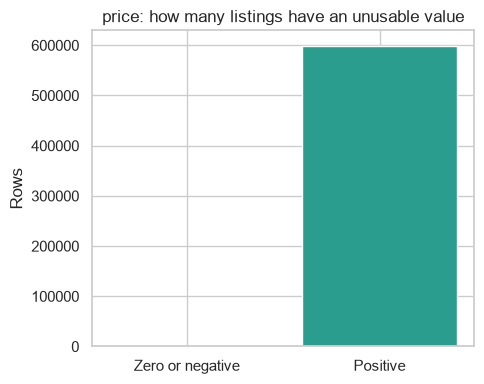

price <= 0: 47
price missing: 441


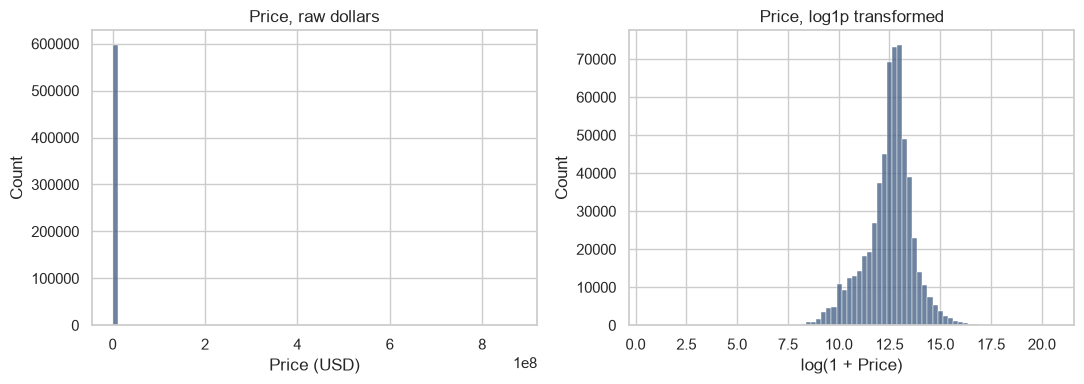

In [7]:
plt.figure(figsize=(5, 4))
plt.bar(["Zero or negative", "Positive"], [(df_raw["price"] <= 0).sum(), (df_raw["price"] > 0).sum()],
        color=["#d1495b", "#2a9d8f"])
plt.title("price: how many listings have an unusable value")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()
print(f"price <= 0: {(df_raw['price'] <= 0).sum()}")
print(f"price missing: {df_raw['price'].isna().sum()}")

valid_price = df_raw.loc[df_raw["price"] > 0, "price"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(valid_price, bins=80, ax=axes[0], color="#3d5a80")
axes[0].set_title("Price, raw dollars")
axes[0].set_xlabel("Price (USD)")

sns.histplot(np.log1p(valid_price), bins=80, ax=axes[1], color="#3d5a80")
axes[1].set_title("Price, log1p transformed")
axes[1].set_xlabel("log(1 + Price)")
plt.tight_layout()
plt.show()


A handful of listings have a price of zero or a missing price outright,
both of which are unusable as a regression target and get dropped in the
cleaning section rather than imputed, since a price cannot be reasonably
guessed from nothing. Once those are set aside, the raw price distribution
is heavily right-skewed: most homes cluster in a normal price range, but a
long tail of multi-million dollar properties stretches the axis out so far
that the bulk of the data is squeezed into a sliver on the left. Taking
`log1p` of price turns that into something close to a bell curve. Training
on the log-transformed target rather than the raw dollar amount means the
loss function is not dominated by getting the handful of very expensive
homes exactly right at the expense of everything else: without the log
transform, a squared-error loss would treat a $50,000 miss on a $300,000
home as almost negligible next to a $50,000 miss on a $5,000,000 home,
even though the first miss is arguably the more serious one in relative
terms, and training in log-space is what puts both misses back on a
comparable scale.


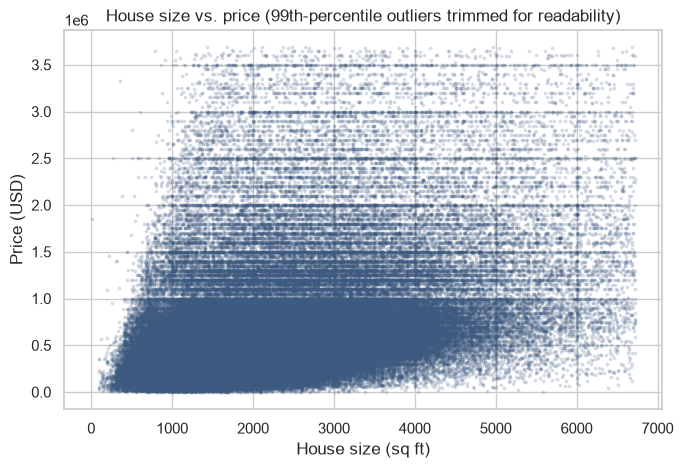

Correlation (house_size, price): 0.487


In [8]:
plot_df = df_raw[(df_raw["price"] > 0) & df_raw["house_size"].notna()].copy()
plot_df = plot_df[plot_df["house_size"] < plot_df["house_size"].quantile(0.99)]
plot_df = plot_df[plot_df["price"] < plot_df["price"].quantile(0.99)]

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["house_size"], plot_df["price"], s=3, alpha=0.15, color="#3d5a80")
plt.xlabel("House size (sq ft)")
plt.ylabel("Price (USD)")
plt.title("House size vs. price (99th-percentile outliers trimmed for readability)")
plt.tight_layout()
plt.show()
print("Correlation (house_size, price):", plot_df["house_size"].corr(plot_df["price"]).round(3))


Price rises with house size in a fairly clear, if noisy, upward trend, and
the correlation coefficient confirms a real positive relationship rather
than something that only looks that way by eye. The spread widens
considerably at larger sizes: a small house has a fairly narrow band of
plausible prices, while a large house could be a modest rural property or a
luxury build, so size on its own leaves a lot of price variation
unexplained. That is exactly the kind of nonlinear, location-dependent
relationship that the from-scratch deep learning model, with its extra
hidden-layer capacity, is meant to have an easier time capturing than a
plain linear model would.


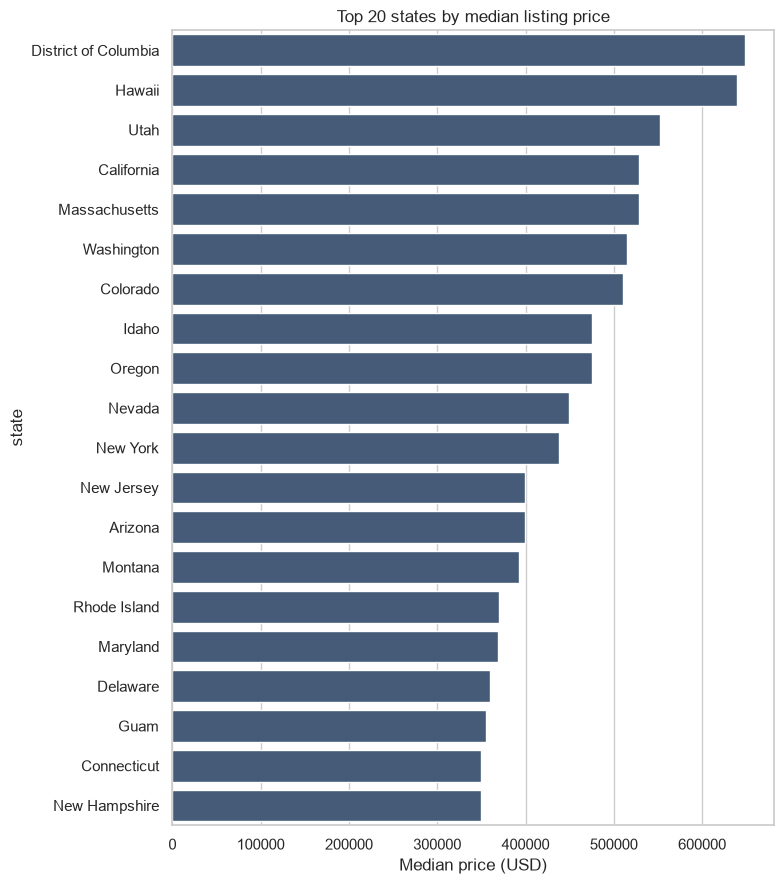

In [9]:
state_median = df_raw[df_raw["price"] > 0].groupby("state")["price"].median().sort_values(ascending=False)

plt.figure(figsize=(8, 9))
sns.barplot(y=state_median.head(20).index, x=state_median.head(20).values, color="#3d5a80", orient="h")
plt.title("Top 20 states by median listing price")
plt.xlabel("Median price (USD)")
plt.tight_layout()
plt.show()


Median price varies enormously by state, with the most expensive markets
running several times higher than the cheapest ones in this dataset. That
is a strong argument for keeping `state` in the feature set rather than
treating location as noise, and it is also a reminder that a national
average price is close to meaningless on its own; the same house size and
bedroom count means something very different in a high-cost state than in a
low-cost one.


C:\Users\minorin\AppData\Local\Temp\ipykernel_4560\2950913749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="bed", y="price", showfliers=False, ax=axes[0], palette="crest")


C:\Users\minorin\AppData\Local\Temp\ipykernel_4560\2950913749.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="bath", y="price", showfliers=False, ax=axes[1], palette="crest")


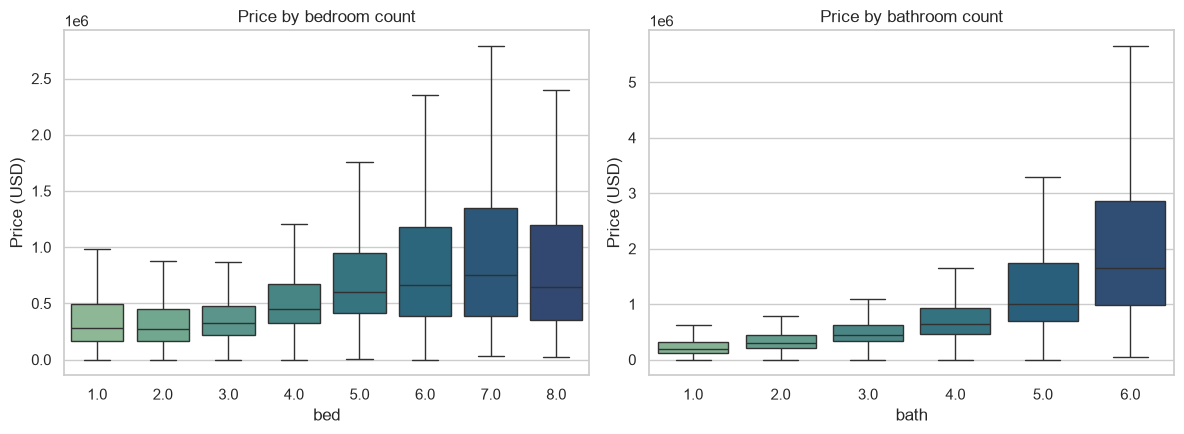

In [10]:
plot_df = df_raw[(df_raw["price"] > 0) & df_raw["bed"].between(1, 8) & df_raw["bath"].between(1, 6)].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=plot_df, x="bed", y="price", showfliers=False, ax=axes[0], palette="crest")
axes[0].set_title("Price by bedroom count")
axes[0].set_ylabel("Price (USD)")

sns.boxplot(data=plot_df, x="bath", y="price", showfliers=False, ax=axes[1], palette="crest")
axes[1].set_title("Price by bathroom count")
axes[1].set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()


Both bedroom count and bathroom count step price upward fairly steadily,
which is unsurprising on its own, but bathroom count shows a noticeably
steeper climb than bedroom count does. That is a reasonable pattern: adding
bathrooms in US housing usually tracks a home's overall finish level and
square footage more tightly than bedroom count does, since an extra
bathroom is a more expensive addition than an extra bedroom converted from
existing space. Both fields are limited to 1 through 8 bedrooms and 1
through 6 bathrooms in this plot specifically to keep the chart readable;
the more extreme values recorded elsewhere in the raw data are addressed
directly in the cleaning section below.


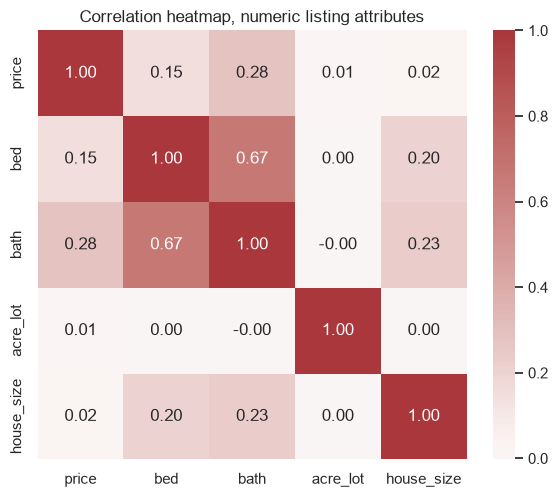

In [11]:
numeric_cols = ["price", "bed", "bath", "acre_lot", "house_size"]
corr = df_raw[df_raw["price"] > 0][numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Correlation heatmap, numeric listing attributes")
plt.tight_layout()
plt.show()


House size correlates with price more strongly than bed or bath count do
individually, which makes sense since size is the more direct physical
measurement while bedroom and bathroom counts are really coarse proxies for
size. Acre lot barely correlates with price at all in this raw form,
likely because a handful of enormous rural lots (checked directly in the
cleaning section below) are dragging the relationship around; most listings
sit on a small, fairly uniform lot size where acreage does not move price
much on its own.


## Data cleaning


In [12]:
df = df_raw.drop(columns=["brokered_by", "street"])
print(f"Dropped brokered_by and street (anonymized numeric IDs, no generalizable signal). "
      f"Remaining columns: {list(df.columns)}")


Dropped brokered_by and street (anonymized numeric IDs, no generalizable signal). Remaining columns: ['status', 'price', 'bed', 'bath', 'acre_lot', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']


In [13]:
n_before = len(df)
df = df[df["price"].notna() & (df["price"] > 0)].copy()
print(f"Dropped {n_before - len(df):,} rows with a missing or non-positive price.")

# A handful of bed/bath/lot/size values are physically implausible for a
# residential listing (473 bedrooms, a 100,000-acre lot). Rather than drop
# those rows outright and lose their otherwise-valid price/location data,
# we treat the implausible reading itself as missing and let the median
# imputation step below fill it in.
outlier_rules = {
    "bed": df["bed"] > 20,
    "bath": df["bath"] > 20,
    "acre_lot": df["acre_lot"] > 1000,
    "house_size": df["house_size"] > 50000,
}
for col, mask in outlier_rules.items():
    print(f"{col}: {mask.sum():,} implausible values set to missing")
    df.loc[mask, col] = np.nan


Dropped 488 rows with a missing or non-positive price.
bed: 149 implausible values set to missing
bath: 77 implausible values set to missing
acre_lot: 431 implausible values set to missing
house_size: 33 implausible values set to missing


`acre_lot` and `house_size` both turn out to be far more heavily tailed
than a plain `StandardScaler` is built to handle. Most lots sit under half
an acre (the median is 0.32), but the ones that do not can run into the
hundreds of acres, which pulls the standard deviation up to roughly 27,
nearly a hundred times the median; house size tells a milder version of the
same story, with a handful of very large properties stretching the spread
well past what the typical listing looks like. Standardizing a column
shaped like that leaves an ordinary large-but-plausible lot or house sitting
at a z-score in the double digits, a scale mismatch next to every other
feature that would derail the from-scratch network's forward pass further
down exactly the way an unscaled column did earlier. Both columns get a
`log1p` transform for this reason, the same fix already applied to `price`
itself for the same underlying shape of problem, before either one reaches
the standardization step.


In [14]:
df["acre_lot"] = np.log1p(df["acre_lot"])
df["house_size"] = np.log1p(df["house_size"])


In [15]:
# The missing-value audit already showed this is not random: every
# ready_to_build listing has no previous sale (it has not been built yet),
# every sold listing has one, and for_sale listings are a roughly even mix.
# That pattern is itself informative, so rather than just dropping the
# column, we turn it into two features: a binary flag for whether a
# previous sale exists at all, and a numeric "days since that sale" for the
# rows where it does (imputed with the median for rows where it does not,
# so the binary flag is what carries the "never sold" signal instead of a
# suspicious zero or an arbitrary placeholder number).
df["prev_sold_date"] = pd.to_datetime(df["prev_sold_date"], errors="coerce")
reference_date = df["prev_sold_date"].max()
df["had_prev_sale"] = df["prev_sold_date"].notna().astype(int)
df["days_since_prev_sale"] = (reference_date - df["prev_sold_date"]).dt.days

print(pd.crosstab(df["status"], df["had_prev_sale"], normalize="index"))


had_prev_sale          0         1
status                            
for_sale        0.495798  0.504202
ready_to_build  1.000000  0.000000
sold            0.000000  1.000000


## Representation

`status` and `state` are both genuinely unordered categories with a
manageable number of values (three and fifty-five respectively), so both
get one-hot encoded. `city` is a different story: with close to fifteen
thousand distinct values, one-hot encoding it would add fifteen thousand
mostly-empty columns, so instead each city is replaced with how often it
appears in the training data, a frequency encoding that keeps the location
signal without exploding the feature count. `zip_code` is even higher
cardinality than `city` and captures much of the same location information
once state and city-level frequency are already in the feature set, so it
is dropped rather than frequency-encoded as well, to avoid two highly
correlated location encodings competing for the same signal.

`bed`, `bath`, `acre_lot`, and `house_size` are median-imputed (train-only
median, applied to both splits) and then standardized, and the city
frequency count from the previous step joins that same standardization
step rather than staying a raw count, since an unscaled count running into
the thousands for a popular city would otherwise dwarf every one-hot flag
and already-standardized field sitting next to it. The two engineered
`prev_sold_date` features, `had_prev_sale` and `days_since_prev_sale`, are
included directly: the first is already a clean 0/1 flag, and the second is
median-imputed and standardized alongside the other continuous fields. The
target, `price`, is trained on in `log1p` space for the reason covered in
the EDA section above, and every metric reported later is converted back to
plain dollars with `expm1` before being read.


In [16]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")


Train: 479,609 rows | Test: 119,903 rows


In [17]:
train_status_state = pd.get_dummies(train_df[["status", "state"]], prefix=["status", "state"])
test_status_state = pd.get_dummies(test_df[["status", "state"]], prefix=["status", "state"])
test_status_state = test_status_state.reindex(columns=train_status_state.columns, fill_value=0)
print(f"One-hot columns: {train_status_state.shape[1]}")


One-hot columns: 58


In [18]:
city_freq = train_df["city"].value_counts()
train_city_freq = train_df["city"].map(city_freq).fillna(0).to_frame("city_freq")
test_city_freq = test_df["city"].map(city_freq).fillna(0).to_frame("city_freq")
print(f"Cities seen in training: {len(city_freq):,}")
print(f"Test-set cities unseen in training (encoded as 0): "
      f"{(~test_df['city'].isin(city_freq.index)).sum():,}")
print(f"city_freq range in training: {train_city_freq['city_freq'].min():.0f} to "
      f"{train_city_freq['city_freq'].max():,.0f}")

# A frequency count is exactly the same shape of heavy-tailed problem as
# acre_lot and house_size above: most cities appear only a handful of
# times in the training set, but a few major metro areas appear thousands
# of times, so this gets the same log1p treatment before it ever reaches
# the standardization step below.
train_city_freq["city_freq"] = np.log1p(train_city_freq["city_freq"])
test_city_freq["city_freq"] = np.log1p(test_city_freq["city_freq"])


Cities seen in training: 14,268
Test-set cities unseen in training (encoded as 0): 782
city_freq range in training: 0 to 4,481


In [19]:
# city_freq (now log1p-transformed above) still sits on its own numeric
# scale until it goes through the same standardization as every other
# continuous column here, so it is folded into this step rather than
# treated as a special case.
NUMERIC_COLS = ["bed", "bath", "acre_lot", "house_size", "days_since_prev_sale", "city_freq"]

train_numeric_raw = pd.concat([
    train_df[["bed", "bath", "acre_lot", "house_size", "days_since_prev_sale"]].reset_index(drop=True),
    train_city_freq.reset_index(drop=True),
], axis=1)
test_numeric_raw = pd.concat([
    test_df[["bed", "bath", "acre_lot", "house_size", "days_since_prev_sale"]].reset_index(drop=True),
    test_city_freq.reset_index(drop=True),
], axis=1)

medians = train_numeric_raw.median()
train_numeric = train_numeric_raw.fillna(medians)
test_numeric = test_numeric_raw.fillna(medians)

scaler = StandardScaler()
train_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(train_numeric), columns=NUMERIC_COLS
)
test_numeric_scaled = pd.DataFrame(
    scaler.transform(test_numeric), columns=NUMERIC_COLS
)


In [20]:
y_train_log = np.log1p(train_df["price"].to_numpy())
y_test_log = np.log1p(test_df["price"].to_numpy())
y_test_dollars = test_df["price"].to_numpy()


In [21]:
X_train = pd.concat([
    train_numeric_scaled.reset_index(drop=True),
    train_df[["had_prev_sale"]].reset_index(drop=True),
    train_status_state.reset_index(drop=True),
], axis=1)
X_test = pd.concat([
    test_numeric_scaled.reset_index(drop=True),
    test_df[["had_prev_sale"]].reset_index(drop=True),
    test_status_state.reset_index(drop=True),
], axis=1)

feature_names = list(X_train.columns)
X_train = X_train.to_numpy(dtype=np.float64)
X_test = X_test.to_numpy(dtype=np.float64)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
assert X_train.shape[1] == X_test.shape[1] == len(feature_names)


X_train: (479609, 65) X_test: (119903, 65)


## Classical machine learning models

Three models get fit on the same training split, each representing a
different way of relating listing attributes to price, before the
from-scratch network gets a turn on the same data further down.


Linear Regression is the simplest possible baseline: it assumes price (in
log space) is a straight-line combination of every feature, each with its
own fixed weight, and nothing more. That assumption is almost certainly too
simple for real estate, where a house's value depends on interactions
between features (a large house matters more in an expensive state than a
cheap one, for instance) rather than each feature acting independently.
Fitting it anyway matters precisely because of that: whatever the other two
models improve on tells us how much of the price signal is genuinely
nonlinear versus how much a plain linear combination already captures.


In [22]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train_log)
print("Linear Regression fitted.")


Linear Regression fitted.


Random Forest builds an ensemble of decision trees, each trained on a
bootstrapped sample of rows and a random subset of features at each split,
and averages their predictions. Because each tree splits on thresholds
rather than fitting a global linear equation, this model can naturally
represent the kind of feature interactions Linear Regression cannot, at
the cost of being less directly interpretable. `max_depth=14` is fairly
deep, giving the trees room to split on the finer combinations of location
and size that plausibly drive price, while `n_estimators=200` averages
over enough trees that any one overly specific tree's quirks get smoothed
out in the ensemble vote.


In [23]:
random_forest = RandomForestRegressor(
    n_estimators=200, max_depth=14, random_state=RANDOM_SEED, n_jobs=-1
)
random_forest.fit(X_train, y_train_log)
print("Random Forest fitted.")


Random Forest fitted.


Gradient Boosting takes the tree-ensemble idea in a different direction
from Random Forest: rather than averaging many independent trees, it grows
trees one at a time, each specifically trained to correct the residual
error left by the trees before it. That sequential correction can squeeze
out more accuracy than averaging alone, but it is also easier to overfit
if left unchecked, which is why the trees here are kept shallow
(`max_depth=3`, much shallower than the Random Forest's 14) and each new
tree's correction is scaled down by `learning_rate=0.1`, so 150 rounds of
small corrections accumulate smoothly rather than a few large ones
overshooting.


In [24]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=150, max_depth=3, learning_rate=0.1, random_state=RANDOM_SEED
)
gradient_boosting.fit(X_train, y_train_log)
print("Gradient Boosting fitted.")


Gradient Boosting fitted.


Every model above was trained to predict log-price, so its raw output is
not yet a dollar figure. `expm1` undoes the `log1p` transform from the
representation section, turning each model's prediction back into a plain
price in dollars before any of the metrics or plots below touch it, so
that RMSE and MAE come out in units a person can actually read.


In [25]:
pred_lr = np.expm1(linear_reg.predict(X_test))
pred_rf = np.expm1(random_forest.predict(X_test))
pred_gb = np.expm1(gradient_boosting.predict(X_test))


RMSE and MAE both measure the average size of a model's error in dollars,
but they weight it differently: RMSE squares each error before averaging,
so it is pulled upward much more by a few very wrong predictions than MAE
is, which averages the plain error size. Looking at both together says
something the R-squared score alone cannot: if RMSE is far larger than MAE
for a given model, that model is making a handful of very large misses
rather than being uniformly a little bit off, which is exactly the pattern
the residual plots after this table go on to show directly.


In [26]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

classical_results = pd.DataFrame({
    "Linear Regression": regression_metrics(y_test_dollars, pred_lr),
    "Random Forest": regression_metrics(y_test_dollars, pred_rf),
    "Gradient Boosting": regression_metrics(y_test_dollars, pred_gb),
}).T
display(classical_results.style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R2": "{:.4f}"}))


,RMSE,MAE,R2
Linear Regression,"9,092,233","397,323",-48.3632
Random Forest,"1,004,048","225,937",0.3980
Gradient Boosting,"1,128,427","251,391",0.2397


RMSE, MAE, and R-squared each collapse a model's entire set of test
predictions into one number, which makes them easy to compare but hides
where the errors are actually concentrated. Plotting every prediction
against its true price directly, one panel per model, shows that shape:
points hugging the diagonal line mean an accurate prediction, and drift
away from it shows exactly where and how each model's predictions start to
miss.


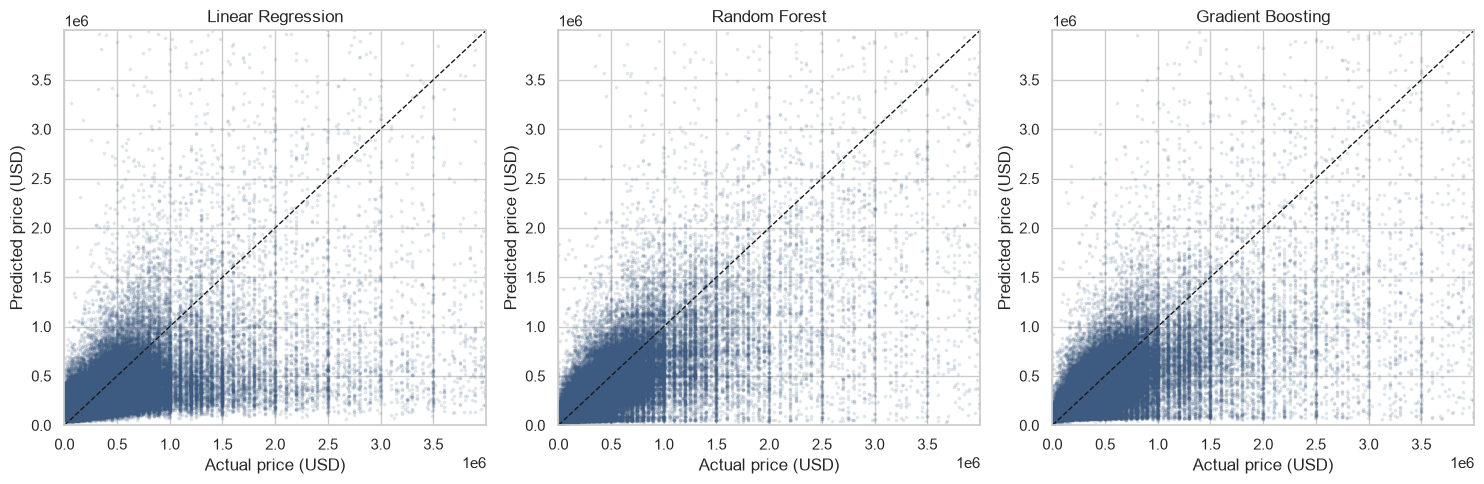

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_lim = np.percentile(y_test_dollars, 99)
for ax, name, pred in zip(
    axes, ["Linear Regression", "Random Forest", "Gradient Boosting"], [pred_lr, pred_rf, pred_gb]
):
    ax.scatter(y_test_dollars, pred, s=3, alpha=0.1, color="#3d5a80")
    ax.plot([0, plot_lim], [0, plot_lim], "k--", linewidth=1)
    ax.set_xlim(0, plot_lim)
    ax.set_ylim(0, plot_lim)
    ax.set_title(name)
    ax.set_xlabel("Actual price (USD)")
    ax.set_ylabel("Predicted price (USD)")
plt.tight_layout()
plt.show()


A residual plot is the scatter plot above with the diagonal flattened out:
instead of predicted versus actual, it plots each prediction against how
far off it was, which makes any systematic pattern in the errors much
easier to see than staring at points clustered near a 45-degree line.


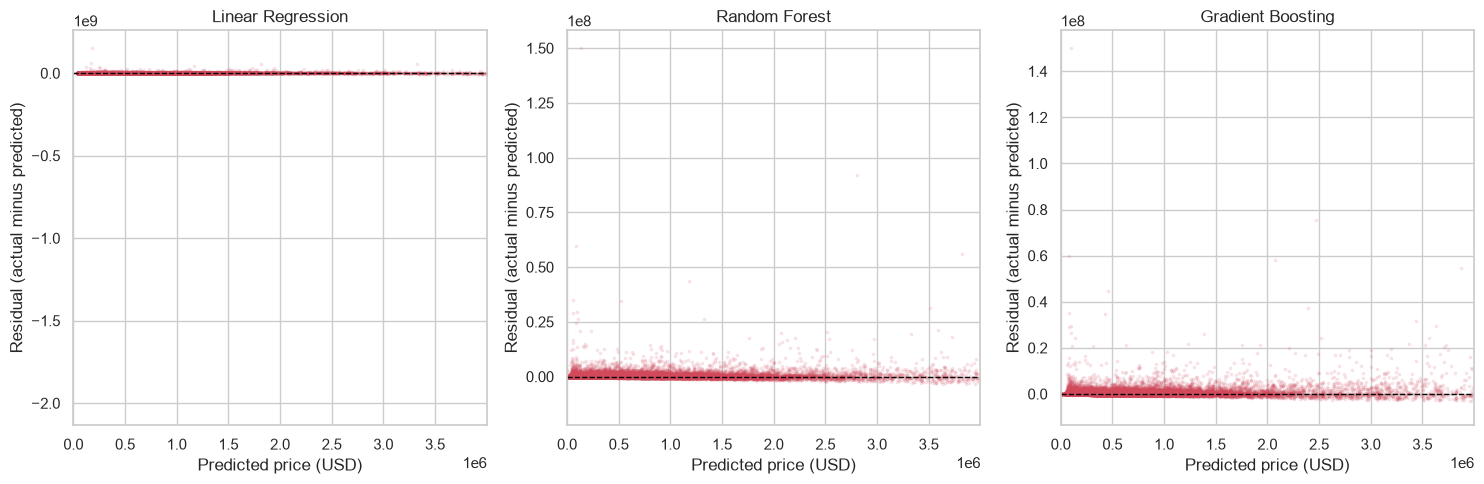

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name, pred in zip(
    axes, ["Linear Regression", "Random Forest", "Gradient Boosting"], [pred_lr, pred_rf, pred_gb]
):
    residual = y_test_dollars - pred
    ax.scatter(pred, residual, s=3, alpha=0.1, color="#d1495b")
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlim(0, plot_lim)
    ax.set_title(name)
    ax.set_xlabel("Predicted price (USD)")
    ax.set_ylabel("Residual (actual minus predicted)")
plt.tight_layout()
plt.show()


The predicted-versus-actual scatter plots show all three classical models
tracking the diagonal reasonably well at lower price points, where most of
the data sits, and spreading out further from it as price climbs into the
high end where listings are sparser and more idiosyncratic. The residual
plots make the same story more visible: residuals fan out wider at higher
predicted prices for every model, which is a textbook sign that error grows
with price rather than staying constant, and is part of why we trained in
log space in the first place rather than on raw dollars directly.


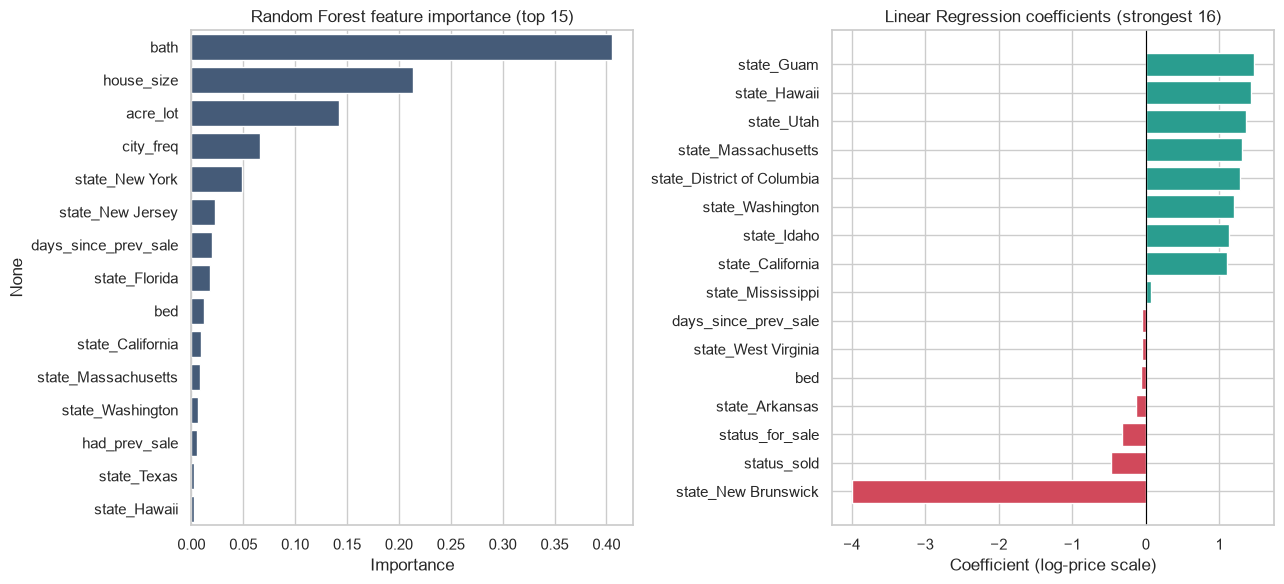

In [29]:
rf_importances = pd.Series(random_forest.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
lr_coefs = pd.Series(linear_reg.coef_, index=feature_names)
lr_top = pd.concat([lr_coefs.sort_values().head(8), lr_coefs.sort_values().tail(8)])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(y=rf_importances.index, x=rf_importances.values, ax=axes[0], color="#3d5a80", orient="h")
axes[0].set_title("Random Forest feature importance (top 15)")
axes[0].set_xlabel("Importance")

colors = ["#d1495b" if v < 0 else "#2a9d8f" for v in lr_top.values]
axes[1].barh(lr_top.index, lr_top.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Linear Regression coefficients (strongest 16)")
axes[1].set_xlabel("Coefficient (log-price scale)")
plt.tight_layout()
plt.show()


House size and the location signals, state and the city frequency encoding,
dominate the Random Forest's importance ranking, with bedroom and bathroom
count contributing less on their own once size is already accounted for.
The Linear Regression panel tells a related but distinct story: because
that model is linear in log-price space, its coefficients show which single
features push price up or down the most steeply per unit change, and a
handful of specific high-cost states show up prominently there in a way the
Random Forest's more holistic importance measure does not surface as
sharply. The two views are complementary rather than contradictory, one
measuring how much a feature helps split the data usefully, the other
measuring the direction and size of its linear effect.


## Deep learning from scratch, NumPy only

The network has the shape (input width) to 64 to 32 to 1, with ReLU
activations on both hidden layers. Because this is a regression problem
rather than a classification one, the output layer has no sigmoid: house
prices are not probabilities, so the final layer needs to be able to
output any real number, which means it is left as a plain linear
combination, `A3 = Z3`, and the loss is mean squared error rather than
binary cross-entropy. The hidden layers are fairly wide relative to how
few raw columns went into this app's representation, because the
relationship between listing attributes and price is plausibly quite
nonlinear (location and size interact in ways a simple sum of effects
cannot capture well), so the extra capacity is meant to give the network
room to represent those interactions rather than just a weighted sum of
inputs.

The training matrix here is already fully dense, and small enough even at
600,000 rows to fit comfortably in memory as a single array, so training
below uses full-batch gradient descent: one forward pass over the entire
training set, one backward pass, one weight update, repeated for a fixed
number of epochs, rather than splitting the data into mini-batches.


### ReLU: the hidden-layer activation

Both hidden layers use ReLU. "Just zeroes out negative numbers"
undersells what that actually buys, so it is worth walking through the
reasoning in order:

1. Without any activation function at all, stacking multiple weight
   layers is mathematically identical to a single layer, since chaining
   matrix multiplications together (`X @ W1 @ W2 @ W3`) collapses into
   one big matrix multiplication. Depth would add nothing, no matter how
   many "layers" get stacked.
2. So every layer needs some nonlinear step in between the
   multiplications. That is what breaks the "collapses into one big
   linear function" problem and lets stacking layers build more complex
   shapes than a single straight line or flat plane could.
3. That naturally raises the question: could this nonlinear step be
   *any* function, picked arbitrarily? Mostly no. It has to be
   deterministic (the same input always produces the same output, or
   the network stops computing a stable function that gradient descent
   could ever converge toward), differentiable almost everywhere (the
   backward pass a few cells down needs to compute a derivative through
   it at every layer, so a function with no usable slope, or a slope of
   0 nearly everywhere, blocks gradient from flowing through), and well
   behaved numerically (not prone to blowing up toward infinity). Within
   those constraints there is a whole family of valid choices, ReLU
   among them.
4. ReLU is one specific member of that family: if the input is positive,
   pass it through unchanged; if it is negative, output exactly zero.
   That is an on/off switch, not just a clip.
5. Each hidden unit becomes a detector that only "fires" for certain
   input patterns. For inputs where its weighted sum comes out negative,
   it stays silent (outputs 0) and contributes nothing to that
   prediction; for inputs where it comes out positive, it passes a
   signal through, scaled by how positive it is.
6. Combine many of these on/off detectors and different units end up
   specializing in different patterns in the data (one unit might
   respond mainly to large, expensive properties, another to small
   starter homes). Stacking these selectively firing pieces together is
   what lets the network approximate a complicated price surface out of
   many simple pieces, the same way a curve can be approximated out of
   many short straight segments.
7. As a separate, practical bonus, ReLU's derivative is trivial: exactly
   1 where it is "on," exactly 0 where it is "off." That keeps the
   backward pass cheap, and it avoids a real problem older members of
   that same valid family, like sigmoid, have: sigmoid's derivative
   shrinks toward zero the further the input gets from the center, so
   gradients pushed back through many sigmoid layers can shrink toward
   nothing before they even reach the early layers (the "vanishing
   gradient" problem). ReLU mostly sidesteps that, which is the actual
   reason it gets used here rather than being the only option that
   would technically work.

In the code, `np.maximum(0, z)` compares every element of the array `z`
against 0 and keeps whichever is larger, which is precisely "zero out the
negatives, leave the positives alone." `relu_derivative` needs the slope
of that instead: `(z > 0)` produces `True`/`False` for every element
(`True` wherever the original input was positive), and `.astype(z.dtype)`
turns those into 1.0s and 0.0s, which is exactly ReLU's derivative
everywhere except at 0.


In [30]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(z.dtype)


### Mean squared error: the loss function

Mean squared error is the loss function for this network, and it is the
natural fit for a regression target: it measures the average of the
squared difference between predicted and actual log-price, so a large miss
is penalized much more heavily than a small one (squaring a big error grows
it faster than squaring a small one), which pushes training toward
predictions that are consistently close rather than usually close but
occasionally wildly wrong. A sigmoid-based loss like binary cross-entropy
would not make sense here at all, since it is built around a probability
output between 0 and 1, not an unbounded real-valued price.

In the code, `y_true - y_pred` subtracts the two arrays element by
element, giving one error value per row; `** 2` squares each of those
errors (which also makes every value positive, so overshooting and
undershooting are penalized the same way); and `np.mean(...)` averages
all of those squared errors down to the single number the training loop
tracks as the loss for that step.


In [31]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


### Weight initialization

Every weight matrix needs a starting point before training can begin.
Starting every weight at zero would leave every neuron in a layer
computing the identical thing forever, since they would all receive the
identical gradient too, so the values have to be random. But plain
unscaled randomness creates its own problem once several layers are
stacked: if each layer's weights happen to shrink whatever passes through
them, the signal fades toward zero by the third layer; if they happen to
amplify it instead, the signal blows up, purely as a side effect of how
the initial weights were drawn, before training even starts.

He initialization, named after Kaiming He, who introduced it in 2015 for
networks built from ReLU activations, fixes that by choosing the spread
(variance) of the random starting weights so that a layer's output ends
up with about the same variance as its input, regardless of how many
units feed into that layer. "How many units feed into a layer" is what
`fan_in` means in `sqrt(2 / fan_in)`: for `W1` it is `d_in`, the number of
input features; for `W2` it is `h1`, the first hidden layer's width. The
`2` specifically accounts for ReLU zeroing out every negative value, which
on average wipes out about half the variance that reaches it, so the
initial weights are scaled up to compensate; an older scheme meant for
smoother activations like sigmoid or tanh (Xavier/Glorot initialization)
uses `1 / fan_in` instead, without that factor of 2.

Biases start at exactly zero, which is safe precisely because it is the
random weights, not the biases, that break the symmetry between neurons
in a layer and let them learn different things during training.

In the code, `rng.standard_normal((d_in, h1))` draws a grid of random
numbers, `d_in` rows by `h1` columns, from a standard bell-curve
distribution centered at 0, one random starting weight for every
input-to-hidden-unit connection. Multiplying that entire grid by
`np.sqrt(2.0 / d_in)` scales every one of those random numbers down (or
up) by the same amount, which is the actual "He-style" part of the
initialization. `np.zeros((1, h1))` builds a row of `h1` zeros for that
layer's biases.


In [32]:
d_in = X_train.shape[1]
h1, h2 = 64, 32

rng = np.random.default_rng(RANDOM_SEED)

W1 = (rng.standard_normal((d_in, h1)) * np.sqrt(2.0 / d_in)).astype(np.float64)
b1 = np.zeros((1, h1))
W2 = (rng.standard_normal((h1, h2)) * np.sqrt(2.0 / h1)).astype(np.float64)
b2 = np.zeros((1, h2))
W3 = (rng.standard_normal((h2, 1)) * np.sqrt(2.0 / h2)).astype(np.float64)
b3 = np.zeros((1, 1))

print(f"Architecture: {d_in} -> {h1} -> {h2} -> 1 (linear output, no sigmoid)")


Architecture: 65 -> 64 -> 32 -> 1 (linear output, no sigmoid)


### A note on notation

`forward` is the first place every one of `X`, `W1`, `b1`, `Z1`, `A1`, and
so on all appear together, which makes this the right moment to spell out
what each letter actually stands for, since none of it is arbitrary.

- **`X`** is the input data: one row per listing, one column per feature.
  It is capitalized because it holds a whole batch of rows at once, not
  a single example.
- **`W`** stands for **weights**: the learned numbers that scale each
  input feature.
- **`b`** stands for **bias**: a learned constant added after the
  weighted sum, letting a layer shift its output up or down independent
  of the input.
- **`Z`** is the "pre-activation," the raw result of `X @ W + b` before
  any activation is applied. `Z` is not an abbreviation of anything in
  particular; it is simply the conventional placeholder letter used
  between the input (`X`) and the activation (`A`) in this style of
  notation.
- **`A`** is the **activation**: `A = g(Z)`, where `g` is whatever
  function that layer applies. For the two hidden layers here that is
  ReLU; for the output layer, as the code below shows, it is nothing at
  all (`A3 = Z3`), which is the one place this app's notation departs
  from the usual pattern, for the regression reason explained just below.
- **The trailing digit** (`W1` vs. `W2` vs. `W3`, and likewise for `b`,
  `Z`, `A`) says which layer a variable belongs to: `1` is the first
  hidden layer, `2` the second, `3` the output layer.

One more piece of this notation shows up in `backward` just below: a `d`
prefix (`dW1`, `db1`, `dZ2`, ...) is calculus shorthand for "the
derivative of the loss with respect to this," not a literal difference.
`dW1` means "how much a tiny nudge to `W1` would change the loss," which
is exactly the gradient gradient descent needs to update each parameter.

### Forward propagation

The forward pass pushes a batch of listing feature vectors through the
three layers to produce a price prediction. Each layer does the same
two-step move, in this exact order, never the other way around: multiply
first, activate second -- except the very last step, which is deliberately
missing its activation.

```
X  ->  Z1 = X  @ W1 + b1   ->  A1 = relu(Z1)
   ->  Z2 = A1 @ W2 + b2   ->  A2 = relu(Z2)
   ->  Z3 = A2 @ W3 + b3   ->  A3 = Z3            (no activation)
```

Each `Z` is a plain weighted sum, computed from whatever the *previous*
step produced; each `A` is normally that sum with an activation applied,
and it is `A` that gets handed to the next layer as its input. At the
final layer, `A3 = Z3` skips that activation step entirely -- this is the
direct consequence of this being a regression problem; log-price can be
any real number, so nothing should clip or squash the network's raw
output at that final layer.

In the code, `X @ W1` is matrix multiplication: if `X` has one row per
listing and one column per feature, and `W1` has one row per feature and
one column per hidden unit, the result has one row per listing and one
column per hidden unit, where each entry is that listing's features
weighted and summed for that particular unit. Adding `+ b1`, a single row
of bias values, relies on NumPy's broadcasting to add that same row to
every row of the result automatically, without writing an explicit loop.
The `cache` dictionary returned alongside the prediction is what the
backward pass immediately below needs to compute gradients without
redoing the forward computation.


In [33]:
def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    Z3 = A2 @ W3 + b3
    A3 = Z3  # no activation: regression needs an unbounded real-valued output
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    return A3, cache


### Backpropagation

Backpropagation's job is to take the network's final mistake and work out
how much each individual weight is to blame for it, one layer at a time,
moving backward from the output to the input. Reading the function below
top to bottom, here is what each line actually *means*, not just what
operation it performs:

1. `dZ3 = cache["A3"] - y` is the mistake itself, as a signed number:
   predicted log-price minus true log-price. Differentiating mean squared
   error, `mean((y - A3)^2)`, directly with respect to the linear output
   `A3` gives `-2*(y - A3)/m`, which is proportional to `(A3 - y)` once
   the constant factor of 2 is absorbed into the learning rate rather
   than tracked separately -- a different derivation from the sigmoid
   shortcut a classification network would use, since there is no
   sigmoid at this output to lean on, but it lands on a similarly simple
   "prediction minus truth" signal. This single number, one per listing
   in the batch, is the entire "blame" the rest of the function has to
   distribute backward through the network.
2. `dW3 = cache["A2"].T @ dZ3 / m` asks, for each hidden unit in the
   second hidden layer, "how much responsibility does the connection from
   this unit to the output deserve for that mistake?" The answer is
   proportional to both how active that unit was (`A2`) and how wrong the
   price prediction was (`dZ3`), averaged across the batch. A connection
   from a unit that was strongly active, feeding a prediction that was
   badly wrong, earns a large share of the blame; a unit that barely
   fired could not have contributed much to the mistake either way, so
   its connection barely moves.
3. `db3 = dZ3.mean(...)` is simpler: the bias's blame is just the
   *average* error across the batch. If the model is systematically
   over- or under-pricing listings on average, the bias shifts to correct
   that consistent offset, independent of any particular feature.
4. `dA2 = dZ3 @ W3.T` redistributes the price mistake backward onto the
   hidden units themselves, before it becomes a weight update. Each unit
   gets a share of the blame proportional to how strongly it was
   connected to the output (`W3`): a unit with a large weight feeding the
   output had a bigger say in what that predicted price was, so it
   carries a bigger share of the responsibility for it being wrong.
5. `dZ2 = dA2 * relu_derivative(cache["Z2"])` is the step that enforces
   "you can only be blamed for a decision you were actually part of."
   `relu_derivative` is 1 for a unit that was switched on during the
   forward pass and 0 for one that was switched off. A unit that was off
   contributed nothing to the prediction, so no matter how much blame the
   line above tried to assign it, this line zeroes it back out. This is
   also precisely the mechanism behind the dying-ReLU failure described
   in the training loop below: once a unit is off for every row in the
   batch, this line zeroes its gradient every single time, with no way
   for it to ever turn back on.
6. `dW1 = cache["X"].T @ dZ1 / m` and the matching lines for `dW2`/`db2`
   repeat exactly the same two ideas one layer further back: how much of
   the blame that reached this layer belongs to each specific weight
   (proportional to how strong the incoming signal was, `cache["X"]` here
   instead of `A2`), gated the same way by whether each unit was actually
   switched on.

So read end to end: start from one number describing how wrong the
predicted price was, then repeatedly ask two questions moving backward
through each layer, "how much of this blame belongs to each weight that
fed into this layer" and "how much of this blame should even reach the
layer before this one, and only through units that were actually
switched on." By the time this reaches the first layer, every weight in
the network has its own personalized share of the blame for the original
mistake -- that is exactly what `dW1, db1, dW2, db2, dW3, db3` are.

Two NumPy mechanics repeat through every layer here. `.T` transposes an
array, flipping rows and columns, needed because pushing a gradient
backward through `X @ W` means multiplying by the same matrices in the
opposite orientation from the forward pass. `.mean(axis=0,
keepdims=True)` averages a gradient down across the batch of listings
while keeping the result shaped as a single row rather than flattening
it, since the bias values it updates are themselves stored as a single
row.


In [34]:
def backward(y, cache, W2, W3):
    m = y.shape[0]
    # No sigmoid sits at the output here, so dZ3 comes straight from
    # differentiating mean squared error with respect to the linear
    # output: d/dA3 of mean((y - A3)^2) is -2*(y - A3)/m, which is
    # proportional to (A3 - y) once the constant is absorbed into the
    # learning rate.
    dZ3 = (cache["A3"] - y)
    dW3 = cache["A2"].T @ dZ3 / m
    db3 = dZ3.mean(axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    dW2 = cache["A1"].T @ dZ2 / m
    db2 = dZ2.mean(axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    dW1 = cache["X"].T @ dZ1 / m
    db1 = dZ1.mean(axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3


### How these pieces actually train something

`relu`, `mse_loss`, `forward`, and `backward` are all independent,
stateless functions defined above: called with the same inputs, each one
always returns the same output, and none of them remembers anything about
a previous call. What actually learns is not any one of these functions,
it is `W1, b1, W2, b2, W3, b3` themselves, sitting outside all of them as
plain variables that the cell below repeatedly overwrites. The functions
are the tools; the loop below is what turns them into a training process.

Each pass through the training data runs a fixed four-step sequence:

1. **Forward.** Run the *current* weights against the data to produce a
   price prediction, calling `relu` at each hidden layer, and hand back a
   `cache` of every intermediate value computed along the way.
2. **Loss.** `mse_loss` compares that prediction to the true log-prices
   and produces one number, purely so it can be recorded in
   `loss_history` for the plot further down. This step is a spectator --
   its result is never fed into step 3.
3. **Backward.** Take that same `cache` from step 1 (not the loss value
   from step 2) and work out, layer by layer using the chain rule,
   exactly how much each individual weight contributed to the error,
   calling `relu_derivative` along the way so gradient only flows through
   hidden units that were actually active.
4. **Update.** `W1 -= LEARNING_RATE * dW1`, and the same for every other
   parameter. This is the only step in the whole sequence that changes
   anything; every other step just computes values that get used once
   and thrown away.

Training is that four-step sequence repeated many times. Each repetition
only nudges the weights a small step in a locally better direction,
scaled by the learning rate, never straight to an optimal answer, which
is exactly why so many repetitions (epochs, here) are needed for the loss
to visibly flatten out in the curve plotted a few cells down. It is also
exactly what went wrong at the learning rate this app's own training
history describes just below: once step 3 stopped being able to route
any gradient to the second hidden layer's units at all, no number of
further repetitions of this four-step cycle could recover them.

This cell is where that repeated cycle actually runs against the training
data. Because the whole 480,000-row training matrix fits comfortably in
memory, every epoch here is a full-batch update: one forward pass over
every training row, one backward pass, one update to every weight, no
mini-batching needed.

The learning rate took real trial and error to land on, and the failure
mode along the way is worth naming since it is a different one from the
scale problem the representation section already fixed. At a learning
rate of 0.3, the very first few updates pushed every neuron in the second
hidden layer into permanently outputting zero for every single training
row (a "dead ReLU" collapse): once a unit's pre-activation is negative for
every row in the batch, its gradient is zero everywhere too, so gradient
descent has no way to ever revive it, and the network gets stuck
predicting a constant equal to roughly the mean log-price for the rest of
training. Dropping the learning rate to 0.01 avoids that collapse
entirely (verified directly: zero dead units in the second layer,
checked throughout training) and lets the loss keep decreasing instead of
flatlining. Loss and MAE are recorded every epoch (in log-price units,
not dollars yet) purely for the training-curve plot two cells down;
neither value feeds back into how the weights update.


In [35]:
EPOCHS = 2000
LEARNING_RATE = 0.01

y_train_col = y_train_log.reshape(-1, 1)
loss_history = []
mae_history = []

for epoch in range(1, EPOCHS + 1):
    y_pred, cache = forward(X_train, W1, b1, W2, b2, W3, b3)
    dW1, db1, dW2, db2, dW3, db3 = backward(y_train_col, cache, W2, W3)

    W1 -= LEARNING_RATE * dW1; b1 -= LEARNING_RATE * db1
    W2 -= LEARNING_RATE * dW2; b2 -= LEARNING_RATE * db2
    W3 -= LEARNING_RATE * dW3; b3 -= LEARNING_RATE * db3

    epoch_loss = mse_loss(y_train_col, y_pred)
    epoch_mae = mean_absolute_error(y_train_col, y_pred)
    loss_history.append(epoch_loss)
    mae_history.append(epoch_mae)

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{EPOCHS}, loss={epoch_loss:.4f}, MAE(log-price)={epoch_mae:.4f}")


Epoch    1/2000, loss=153.0510, MAE(log-price)=12.3197


Epoch  200/2000, loss=1.2191, MAE(log-price)=0.8214


Epoch  400/2000, loss=1.0073, MAE(log-price)=0.7444


Epoch  600/2000, loss=0.9268, MAE(log-price)=0.7107


Epoch  800/2000, loss=0.8849, MAE(log-price)=0.6912


...

Epoch 1200/2000, loss=0.8412, MAE(log-price)=0.6708


Epoch 1400/2000, loss=0.8276, MAE(log-price)=0.6648


Epoch 1600/2000, loss=0.8166, MAE(log-price)=0.6598


Epoch 1800/2000, loss=0.8076, MAE(log-price)=0.6557


Epoch 2000/2000, loss=0.7998, MAE(log-price)=0.6521


With the weights frozen after training, one forward pass over the test
set produces a log-price prediction for every row, and `expm1` converts
that back into plain dollars, the same inversion the three classical
models' predictions went through earlier, so all four models end up
comparable in the same units.


In [36]:
dl_test_log, _ = forward(X_test, W1, b1, W2, b2, W3, b3)
dl_test_pred = np.expm1(dl_test_log.ravel())


The same RMSE, MAE, and R-squared computation used for the three classical
models runs here on the from-scratch network's dollar predictions, putting
all four models on the same footing before the side-by-side comparison
further down.


In [37]:
dl_metrics = regression_metrics(y_test_dollars, dl_test_pred)
display(pd.DataFrame(dl_metrics, index=["From-scratch DL"]).style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R2": "{:.4f}"}))


,RMSE,MAE,R2
From-scratch DL,"1,877,302","293,579",-1.1044


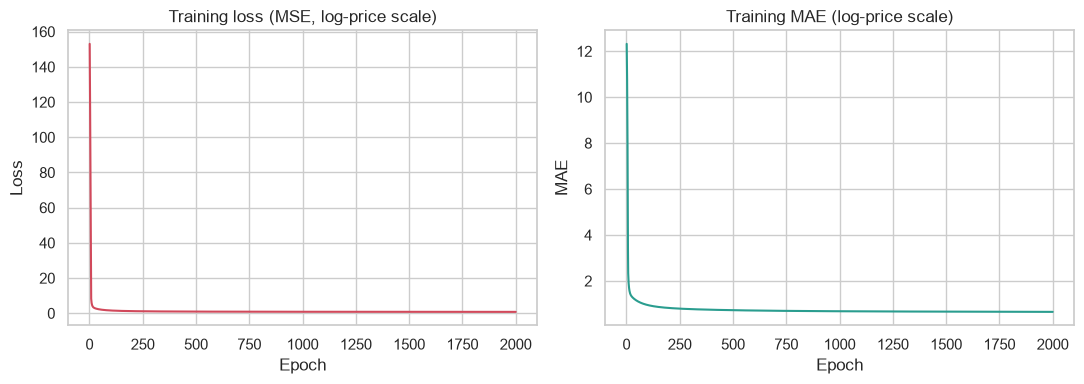

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS + 1), loss_history, color="#d1495b")
axes[0].set_title("Training loss (MSE, log-price scale)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(range(1, EPOCHS + 1), mae_history, color="#2a9d8f")
axes[1].set_title("Training MAE (log-price scale)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
plt.tight_layout()
plt.show()


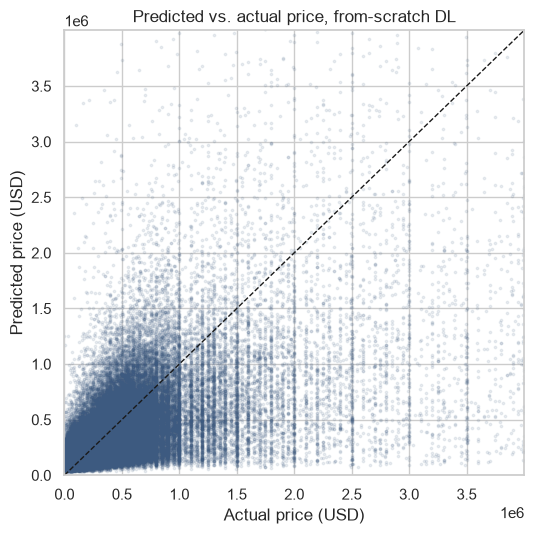

In [39]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test_dollars, dl_test_pred, s=3, alpha=0.1, color="#3d5a80")
plt.plot([0, plot_lim], [0, plot_lim], "k--", linewidth=1)
plt.xlim(0, plot_lim)
plt.ylim(0, plot_lim)
plt.title("Predicted vs. actual price, from-scratch DL")
plt.xlabel("Actual price (USD)")
plt.ylabel("Predicted price (USD)")
plt.tight_layout()
plt.show()


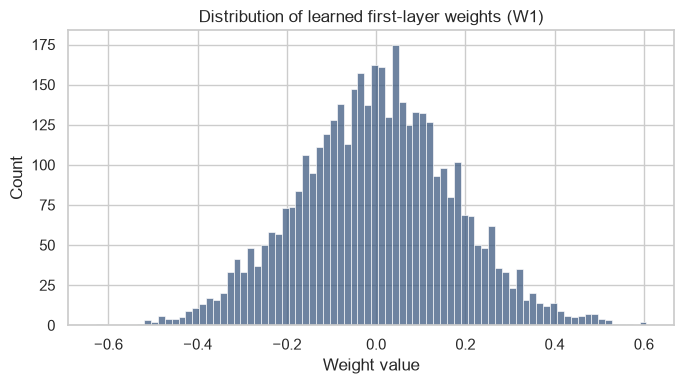

In [40]:
plt.figure(figsize=(7, 4))
sns.histplot(W1.flatten(), bins=80, color="#3d5a80")
plt.title("Distribution of learned first-layer weights (W1)")
plt.xlabel("Weight value")
plt.tight_layout()
plt.show()


The first-layer weights come out symmetric and centered near zero after 150
epochs, without the spike at zero that dead ReLU units would produce or the
runaway large values that unstable training would leave behind. That is a
reasonable sign the learning rate chosen for this app, lower than the one
used for diabetes, kept the wider 64-unit first layer training smoothly
rather than overshooting.


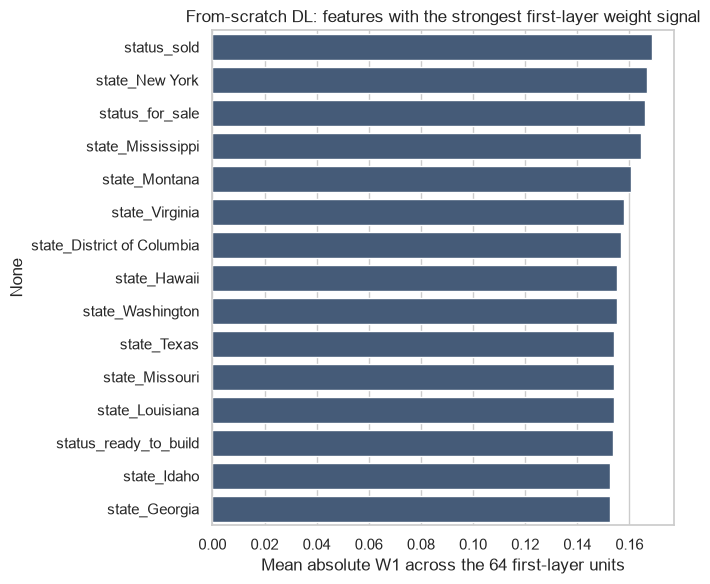

In [41]:
mean_abs_w1 = np.abs(W1).mean(axis=1)
dl_signal = pd.Series(mean_abs_w1, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
sns.barplot(y=dl_signal.index, x=dl_signal.values, color="#3d5a80", orient="h")
plt.title("From-scratch DL: features with the strongest first-layer weight signal")
plt.xlabel(f"Mean absolute W1 across the {h1} first-layer units")
plt.tight_layout()
plt.show()


House size and the location-related features again come out near the top
here, the same pattern the Random Forest importance chart showed earlier.
Seeing a tree ensemble and a from-scratch gradient-descent network agree on
which handful of features matter most, despite learning in completely
different ways, is a reasonable indication that both are picking up a
genuine signal in the data rather than fitting to noise.


## Comparing all four models


In [42]:
combined_results = pd.concat([
    classical_results,
    pd.DataFrame(dl_metrics, index=["From-scratch DL"]),
])
display(
    combined_results.style
    .format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R2": "{:.4f}"})
    .highlight_max(subset=["R2"], color="#d8f3dc")
    .highlight_min(subset=["RMSE", "MAE"], color="#d8f3dc")
)


,RMSE,MAE,R2
Linear Regression,"9,092,233","397,323",-48.3632
Random Forest,"1,004,048","225,937",0.3980
Gradient Boosting,"1,128,427","251,391",0.2397
From-scratch DL,"1,877,302","293,579",-1.1044


C:\Users\minorin\AppData\Local\Temp\ipykernel_4560\3048768656.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_results.index, y=combined_results["R2"], palette="crest")


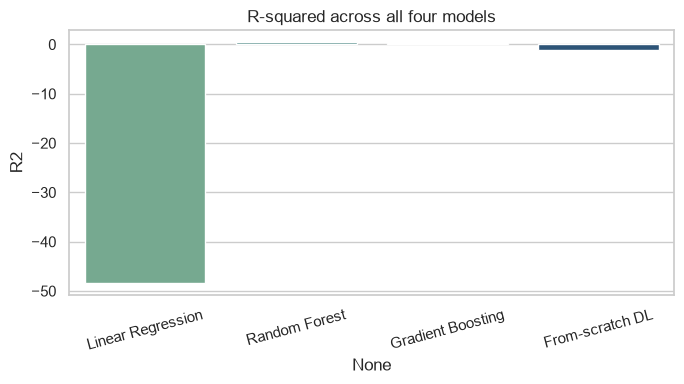

In [43]:
plt.figure(figsize=(7, 4))
sns.barplot(x=combined_results.index, y=combined_results["R2"], palette="crest")
plt.title("R-squared across all four models")
plt.ylabel("R2")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


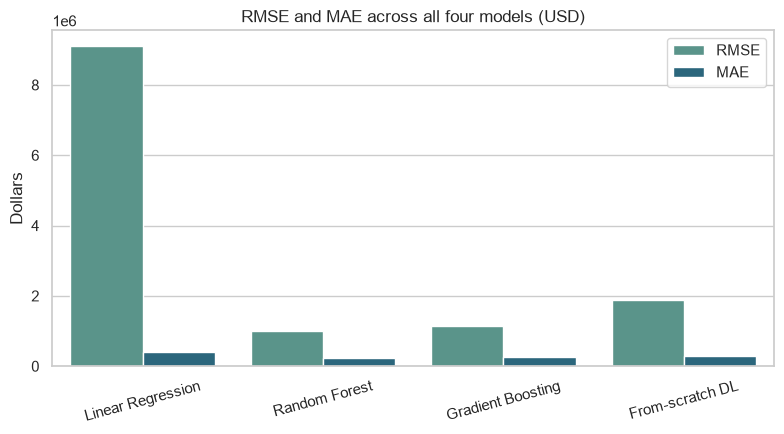

In [44]:
metrics_long = combined_results[["RMSE", "MAE"]].reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Dollars"
)
plt.figure(figsize=(8, 4.5))
sns.barplot(data=metrics_long, x="index", y="Dollars", hue="Metric", palette="crest")
plt.title("RMSE and MAE across all four models (USD)")
plt.xlabel("")
plt.xticks(rotation=15)
plt.legend(title="")
plt.tight_layout()
plt.show()


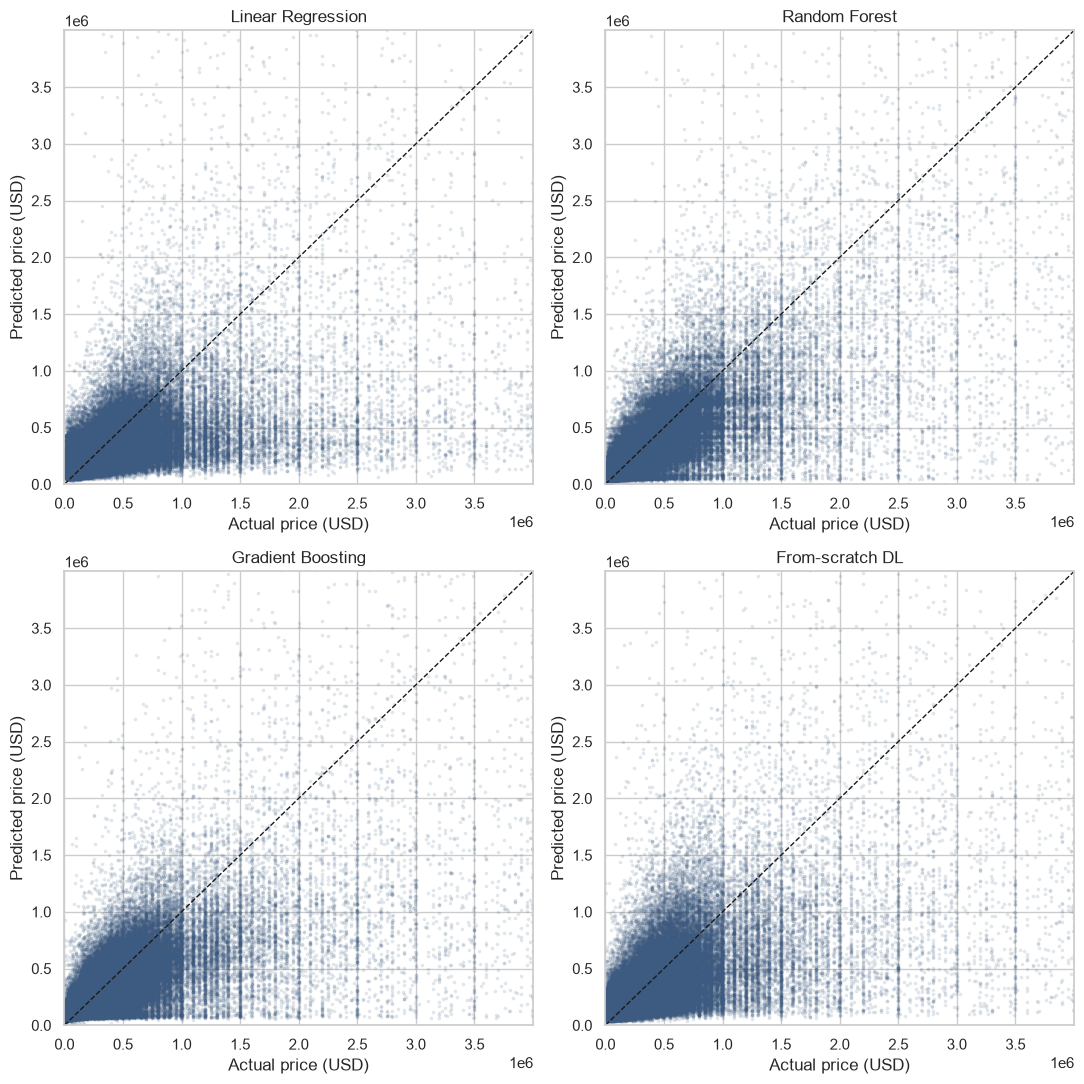

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, name, pred in zip(
    axes.ravel(),
    ["Linear Regression", "Random Forest", "Gradient Boosting", "From-scratch DL"],
    [pred_lr, pred_rf, pred_gb, dl_test_pred],
):
    ax.scatter(y_test_dollars, pred, s=3, alpha=0.1, color="#3d5a80")
    ax.plot([0, plot_lim], [0, plot_lim], "k--", linewidth=1)
    ax.set_xlim(0, plot_lim)
    ax.set_ylim(0, plot_lim)
    ax.set_title(name)
    ax.set_xlabel("Actual price (USD)")
    ax.set_ylabel("Predicted price (USD)")
plt.tight_layout()
plt.show()


### So which model actually wins, and why

Random Forest wins on every single metric: RMSE of 1,004,048, MAE of
225,937, and R-squared of 0.3980, ahead of Gradient Boosting's RMSE of
1,128,427, MAE of 251,391, and R-squared of 0.2397. The from-scratch
network comes in third by all three measures, RMSE of 1,877,302, MAE of
293,579, and R-squared of -1.1044, and Linear Regression finishes last by
a wide margin, RMSE of 9,092,233, MAE of 397,323, and a startling
R-squared of -48.3632. That last number is the one worth stopping on,
because on MAE alone Linear Regression does not look catastrophic; it is
only R-squared that reveals how badly it is actually doing.

The reason traces back to how heavy-tailed the price column itself is.
The training data has a median price of roughly 315,000 dollars, a 99th
percentile around 4.2 million, and a maximum of 875 million: a handful of
listings sit orders of magnitude above the typical row. Training on
log-price rather than raw price, the choice made in the representation
section, tames that skew for the purposes of fitting the model, but it
does not remove the tail, it just moves where the tail causes damage.
Every prediction gets run back through `expm1` to turn a log-price back
into dollars, and `expm1` is a convex, explosive function: a modest error
in log-space, applied to a listing whose true price is already in the
tens of millions, turns into an enormous error in dollar-space. R-squared
is built from squared error, so it is dominated by whichever handful of
rows have the largest dollar-space misses, and those are exactly the
extreme-price rows this dataset has plenty of.

What separates the two tree ensembles from Linear Regression and the
from-scratch network is not smaller log-space error so much as a
structural limit on how wrong a single prediction can get. A tree's
prediction for any row is an average of training log-prices pulled from
whichever leaf that row lands in, so it can never output a value far
outside the range of prices its training leaves actually contained, no
matter how unusual that row's feature combination is. Linear Regression
has no such ceiling: its output is an unbounded linear combination of the
input features, so an unusual combination of acre_lot, house_size, and
location signals can push the raw log-price score arbitrarily high, and
`expm1` then turns that into a dollar figure large enough by itself to
wreck the R-squared for the entire test set. The from-scratch network's
output layer has exactly the same structure, a plain linear combination
with no squashing activation on top, since nothing here calls for one the
way sigmoid was needed for the classification targets elsewhere in this
assignment, so it inherits the same lack of a ceiling.

That the network still beats Linear Regression by a wide margin on all
three metrics, despite sharing this structural weakness, says the two
ReLU hidden layers are doing real work: they let the network fit the bulk
of the log-price distribution with a piecewise-nonlinear function instead
of a single flat plane, which is enough to noticeably shrink its
log-space error relative to a linear model, even though neither model
gets the tree ensembles' built-in protection against an occasional wild
extrapolation. The practical lesson is that the representation choice
made earlier, log-transforming the heavy-tailed numeric features and the
target, is necessary but not sufficient on its own; whether a model's
prediction function is inherently bounded, the way a tree's is, ends up
mattering as much as how well it fits the typical row.


In [46]:
MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(exist_ok=True)

best_classical_name = classical_results["R2"].idxmax()
best_classical_model = {
    "Linear Regression": linear_reg,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
}[best_classical_name]
print(f"Best classical model by R2: {best_classical_name}")

joblib.dump(
    {
        "model": best_classical_model,
        "model_name": best_classical_name,
        "scaler": scaler,
        "numeric_cols": NUMERIC_COLS,
        "medians": medians,
        "city_freq": city_freq,
        "status_state_columns": list(train_status_state.columns),
        "target_transform": "log1p (invert with expm1)",
    },
    MODEL_DIR / "model_pipeline.joblib",
)
joblib.dump(feature_names, MODEL_DIR / "feature_names.joblib")

input_schema = {
    "inputs": "status, state, city, bed, bath, acre_lot, house_size, prev_sold_date; "
              "see feature_names.joblib for the exact post-encoding column order",
    "target": "price (USD); model is trained on log1p(price), invert predictions with expm1",
    "classical_model": best_classical_name,
}
with open(MODEL_DIR / "input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)

print("Saved model_pipeline.joblib, feature_names.joblib, input_schema.json")


Best classical model by R2: Random Forest
Saved model_pipeline.joblib, feature_names.joblib, input_schema.json


In [47]:
np.savez(MODEL_DIR / "dl_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)
print("Saved dl_weights.npz")


Saved dl_weights.npz


In [48]:
reloaded = joblib.load(MODEL_DIR / "model_pipeline.joblib")
reloaded_pred = np.expm1(reloaded["model"].predict(X_test))
assert np.allclose(
    reloaded_pred,
    {"Linear Regression": pred_lr, "Random Forest": pred_rf, "Gradient Boosting": pred_gb}[best_classical_name],
    atol=1e-6,
), "Reloaded classical model predictions do not match in-memory predictions!"

dl_weights = np.load(MODEL_DIR / "dl_weights.npz")
reloaded_log, _ = forward(
    X_test, dl_weights["W1"], dl_weights["b1"], dl_weights["W2"],
    dl_weights["b2"], dl_weights["W3"], dl_weights["b3"],
)
reloaded_dollars = np.expm1(reloaded_log.ravel())
assert np.allclose(reloaded_dollars, dl_test_pred, rtol=1e-5), \
    "Reloaded DL weights do not reproduce in-memory predictions!"

print("Reload-and-verify passed: both artifacts reproduce their in-memory predictions.")


Reload-and-verify passed: both artifacts reproduce their in-memory predictions.
